In [2]:
# BLOCK 1: Load everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data (CHANGE THIS to where your file is)
# Example: df = pd.read_csv('C:/Users/YourName/Downloads/loan_data.csv')
df = pd.read_csv("C:/Users/HP PROBOOK/Downloads/loan_prediction_dataset.csv")  # Put your file path here

print("✅ Data loaded!")
print(f"Shape: {df.shape}")
print(df.head())

✅ Data loaded!
Shape: (2000, 7)
   Age  Income  Credit_Score  Loan_Amount  Loan_Term Employment_Status  \
0   56   81788           334        15022         48          Employed   
1   69  102879           781        21013         24     Self-Employed   
2   46   58827           779        39687         60     Self-Employed   
3   32  127188           364        16886         24        Unemployed   
4   60   25655           307        26256         36        Unemployed   

   Loan_Approved  
0              0  
1              1  
2              0  
3              0  
4              0  


In [3]:
# BLOCK 2: Clean missing data
print("\n🧹 Cleaning data...")
print("Missing values before:", df.isnull().sum().sum())

# Fill empty spots
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

print("Missing values after:", df.isnull().sum().sum())


🧹 Cleaning data...
Missing values before: 0
Missing values after: 0


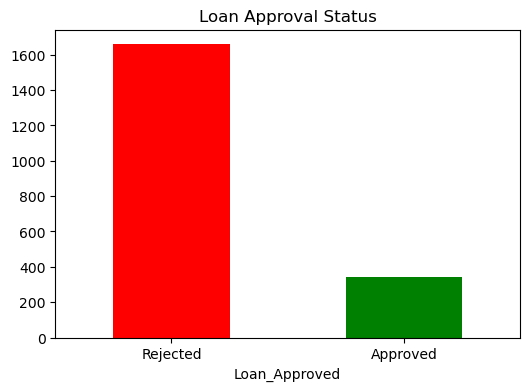


Approval rate: 0.0 %


In [6]:
# BLOCK 3: See loan approvals
plt.figure(figsize=(6,4))
df['Loan_Approved'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Loan Approval Status')
plt.xticks([0,1], ['Rejected', 'Approved'], rotation=0)
plt.show()

print("\nApproval rate:", (df['Loan_Approved'] == 'Y').mean() * 100, "%")

In [7]:
# BLOCK 4: Convert text to numbers
# Your Loan_Approved is already 0/1, so no mapping needed
df['Loan_Approved_num'] = df['Loan_Approved']  # It's already numeric!

# Convert Employment_Status to numbers
employment_map = {'Employed': 1, 'Self-Employed': 2, 'Unemployed': 0}
df['Employment_Status_num'] = df['Employment_Status'].map(employment_map)

# Pick features for prediction (use columns you actually have)
X = df[['Income', 'Loan_Amount', 'Credit_Score', 'Employment_Status_num']]
y = df['Loan_Approved']  # This is already your target (0/1)

print("Ready for training!")
print(f"Features: {X.columns.tolist()}")
print(f"Target: {y.name}")

Ready for training!
Features: ['Income', 'Loan_Amount', 'Credit_Score', 'Employment_Status_num']
Target: Loan_Approved


In [10]:
# BLOCK 5: Train and test the model
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model with more iterations
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Check accuracy
acc = accuracy_score(y_test, predictions)
print(f"\n Model Accuracy: {acc * 100:.2f}%")


 Model Accuracy: 91.75%


In [11]:
# BLOCK 6: Show results
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, predictions)
print("\n Confusion Matrix:")
print(cm)
print("\n Classification Report:")
print(classification_report(y_test, predictions, target_names=['Rejected', 'Approved']))


 Confusion Matrix:
[[311  11]
 [ 22  56]]

 Classification Report:
              precision    recall  f1-score   support

    Rejected       0.93      0.97      0.95       322
    Approved       0.84      0.72      0.77        78

    accuracy                           0.92       400
   macro avg       0.88      0.84      0.86       400
weighted avg       0.91      0.92      0.92       400



In [12]:
# BLOCK 7: Show results in words
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)

print("\n📊 Results breakdown:")
print(f"Correctly predicted approved: {cm[1,1]}")
print(f"Correctly predicted rejected: {cm[0,0]}")
print(f"Wrong predictions: {cm[0,1] + cm[1,0]}")

if acc > 0.7:
    print("\n✅ Good model! Can predict loans with >70% accuracy")
else:
    print("\n⚠️ Model needs improvement - try adding more features")


📊 Results breakdown:
Correctly predicted approved: 56
Correctly predicted rejected: 311
Wrong predictions: 33

✅ Good model! Can predict loans with >70% accuracy
